# Baseline Model Comparison

This notebook evaluates multiple baseline machine learning models for Parkinson’s Disease prediction.

The goal is to identify which algorithm performs best on the selected voice-based features before applying advanced tuning.

# Models Used

The following classification algorithms are used:

- Logistic Regression
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

These models are chosen because they represent different learning approaches and provide a strong baseline comparison.

In [47]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Dataset Loading

The selected feature dataset is loaded from `selected_features.csv`.

- Input Features → Voice-based numerical features
- Target Variable → `status`
    - `1` = Parkinson’s Disease
    - `0` = Healthy

In [48]:
df = pd.read_csv('../data/selected_features.csv')
df.head()

,spread1,PPE,spread2,MDVP:Fo(Hz),status
0,-4.813031,0.284654,0.266482,119.992,1
1,-4.075192,0.368674,0.335590,122.400,1
2,-4.443179,0.332634,0.311173,116.682,1
3,-4.117501,0.368975,0.334147,116.676,1
4,-3.747787,0.410335,0.234513,116.014,1


# Train-Test Split

The dataset is divided into training and testing sets.

- 80% → Training Data
- 20% → Testing Data

`stratify=y` is used to maintain balanced class distribution in both sets.

In [49]:
X= df.drop('status', axis=1)
y = df['status']

print("Features Used: ")
print(X.columns.tolist())

Features Used: 
['spread1', 'PPE', 'spread2', 'MDVP:Fo(Hz)']


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (156, 4)
Testing set size: (39, 4)


# Feature Scaling

Feature scaling is performed using `StandardScaler`.

Scaling is important for:

- Logistic Regression
- SVM
- KNN

It ensures all features have similar ranges and improves model stability.

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

Each model is trained using the scaled training data.

The workflow includes:

1. Model Training
2. Prediction on Test Data
3. Accuracy Calculation
4. Cross Validation

# Baseline Model Performance Results

Multiple machine learning models were evaluated for Parkinson’s Disease prediction using selected voice-based features.

The performance of each model is summarized below.

| Model | Test Accuracy | Cross Validation Accuracy |
|---|---|---|
| Logistic Regression | 92.30% | 82.03% |
| SVM | 87.17% | 85.86% |
| KNN | 87.17% | 85.22% |
| Decision Tree | 84.61% | 83.95% |
| Random Forest | 89.74% | 88.46% |

---

# Key Observations

- Logistic Regression achieved the highest test accuracy.
- Random Forest produced the best cross-validation performance, indicating better generalization.
- Decision Tree showed lower stability compared to ensemble methods.
- SVM and KNN delivered balanced and competitive results.

---

# Conclusion

Among all baseline models:

- Logistic Regression performed best on the test dataset.
- Random Forest showed the most stable overall performance.

These results indicate that voice-based acoustic features are effective for Parkinson’s Disease classification.

In [52]:
models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

In [53]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {'Test Accuracy': acc, 'CV Score': cv_score}

    print(f'{name}')
    print('_'*40)
    print('Test Accuracy: ', acc)
    print('Cross Validation accuracy: ', cv_score)
    print()

Logistic Regression
________________________________________
Test Accuracy:  0.9230769230769231
Cross Validation accuracy:  0.8203629032258066

SVM
________________________________________
Test Accuracy:  0.8717948717948718
Cross Validation accuracy:  0.8586693548387098

KNN
________________________________________
Test Accuracy:  0.8717948717948718
Cross Validation accuracy:  0.8522177419354839

Decision Tree
________________________________________
Test Accuracy:  0.8461538461538461
Cross Validation accuracy:  0.8395161290322581

Random Forest
________________________________________
Test Accuracy:  0.8974358974358975
Cross Validation accuracy:  0.8846774193548388



In [54]:
results_df = pd.DataFrame(results).T
results_df

,Test Accuracy,CV Score
Logistic Regression,0.923077,0.820363
SVM,0.871795,0.858669
KNN,0.871795,0.852218
Decision Tree,0.846154,0.839516
Random Forest,0.897436,0.884677


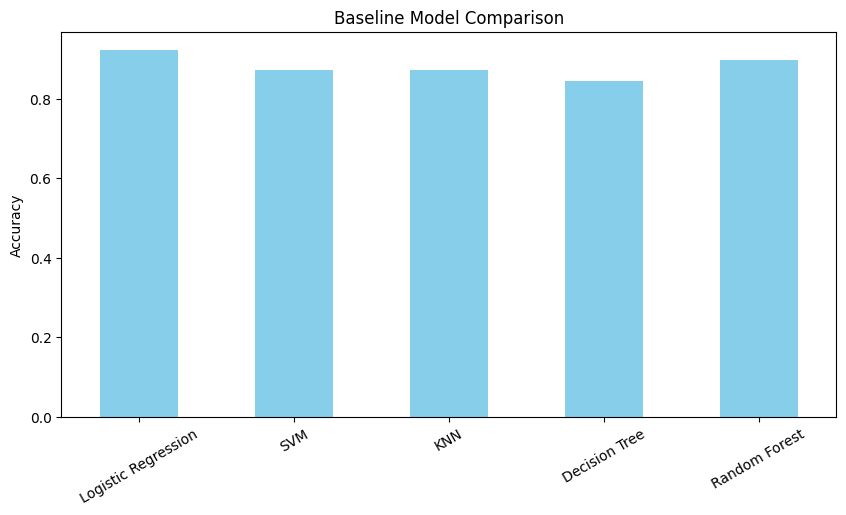

In [55]:
plt.figure(figsize=(10, 5))

results_df['Test Accuracy'].plot(kind='bar', color='skyblue')

plt.title('Baseline Model Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.show()

# Best Baseline Model

The best-performing baseline model was selected based on test accuracy.

- **Best Model:** Logistic Regression
- **Test Accuracy:** 92.30%

---

# Classification Report Analysis

| Metric | Class 0 (Healthy) | Class 1 (Parkinson’s) |
|---|---|---|
| Precision | 1.00 | 0.91 |
| Recall | 0.57 | 1.00 |
| F1-Score | 0.73 | 0.96 |

---

# Key Observations

- The model achieved excellent performance in detecting Parkinson’s patients.
- Recall for Class 1 is 1.00, meaning all Parkinson’s cases were correctly identified.
- Lower recall for healthy patients indicates a few healthy samples were misclassified.
- The overall weighted F1-score shows strong classification performance.

---

# Conclusion

Logistic Regression demonstrated strong predictive capability and achieved the highest baseline accuracy among all evaluated models.

The model performs especially well for identifying Parkinson’s Disease cases using voice-based acoustic features.

In [56]:
bast_model_name = results_df['Test Accuracy'].idxmax()

print('Best Baseline Model:', bast_model_name)

Best Baseline Model: Logistic Regression


In [60]:
best_model = models[bast_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print('\n Classification Report: ')
print(classification_report(y_test, y_pred))


 Classification Report: 
              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.91      1.00      0.96        32

    accuracy                           0.92        39
   macro avg       0.96      0.79      0.84        39
weighted avg       0.93      0.92      0.91        39



# Confusion Matrix Analysis

The confusion matrix evaluates the prediction performance of the Logistic Regression model.

| Metric | Value | Description |
|---|---|---|
| True Positives (TP) | 32 | Correctly predicted Parkinson’s cases |
| True Negatives (TN) | 4 | Correctly predicted healthy cases |
| False Positives (FP) | 3 | Healthy cases predicted as Parkinson’s |
| False Negatives (FN) | 0 | Parkinson’s cases predicted as healthy |

---

# Key Observations

- The model successfully identified all Parkinson’s cases.
- No false negatives were observed, which is important in medical diagnosis.
- A small number of healthy samples were misclassified as positive cases.
- Overall, the model demonstrated strong classification performance and reliability.

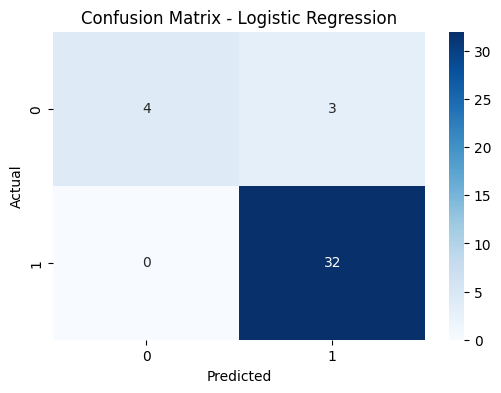

In [61]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {bast_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()